In [1]:
print('hello, I am Seunggeuni!')

hello, I am Seunggeuni!


In [2]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 가상 데이터 생성 (3개의 그룹이 섞여 있다고 가정)
np.random.seed(42)
n_samples = 300

# 그룹 A: 라이트 유저 (낮은 접속, 낮은 결제)
group_a = np.random.multivariate_normal([10, 2, 5000], [[2, 0, 0], [0, 1, 0], [0, 0, 1000000]], 100)
# 그룹 B: 헤비 유저 (높은 접속, 높은 시간)
group_b = np.random.multivariate_normal([25, 8, 20000], [[3, 0, 0], [0, 2, 0], [0, 0, 5000000]], 100)
# 그룹 C: 고과금 유저 (적당한 접속, 매우 높은 결제)
group_c = np.random.multivariate_normal([15, 4, 150000], [[2, 0, 0], [0, 1, 0], [0, 0, 10000000]], 100)

data = np.vstack([group_a, group_b, group_c])
df = pd.DataFrame(data, columns=['sessions', 'play_hours', 'spend'])

# 2. 데이터 표준화 (LPA/GMM은 스케일에 민감하므로 필수!)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [3]:
# 3. 모델 설정 및 학습
# n_components가 바로 우리가 찾고자 하는 '잠재 프로파일의 개수'입니다.
lpa_model = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
df['profile'] = lpa_model.fit_predict(df_scaled)

# 4. 결과 확인 (각 프로파일별 평균값 계산)
profile_summary = df.groupby('profile').mean().reset_index()
print(profile_summary)

   profile   sessions  play_hours          spend
0        0  24.808496    8.018277   20074.173047
1        1  15.102740    4.097903  150240.429872
2        2   9.740869    2.074822    5091.765977


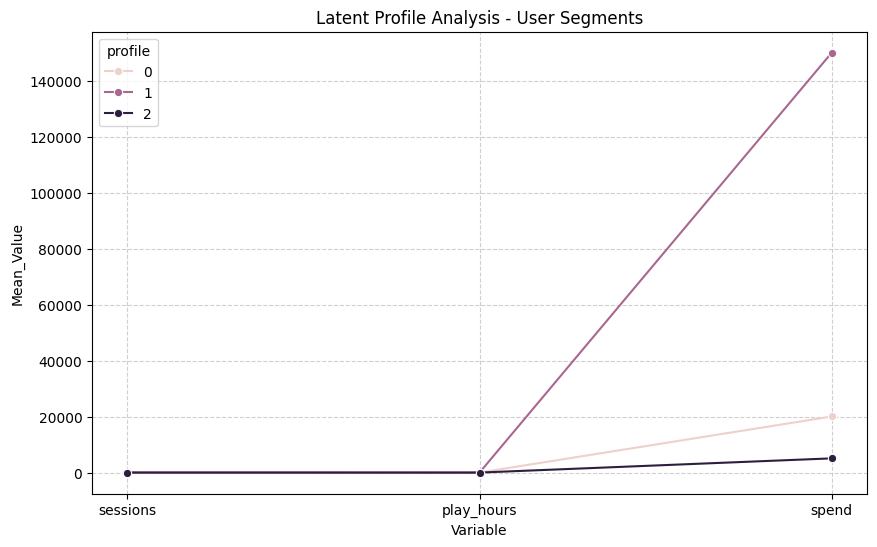

In [4]:
# 5. 프로파일별 특징 시각화 (Line Plot)
profile_melted = profile_summary.melt(id_vars='profile', var_name='Variable', value_name='Mean_Value')

plt.figure(figsize=(10, 6))
sns.lineplot(data=profile_melted, x='Variable', y='Mean_Value', hue='profile', marker='o')
plt.title('Latent Profile Analysis - User Segments')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [5]:
# 1. 모델이 예측한 각 프로파일의 가중치 (Mixing Weights)
weights = lpa_model.weights_

for i, weight in enumerate(weights):
    print(f"Profile {i}의 비중: {weight:.2%}")

Profile 0의 비중: 33.33%
Profile 1의 비중: 33.33%
Profile 2의 비중: 33.33%


In [6]:
# 2. 각 샘플이 각 프로파일에 속할 확률 계산
probs = lpa_model.predict_proba(df_scaled)

# 데이터프레임으로 만들어서 상위 5개만 확인
probs_df = pd.DataFrame(probs, columns=[f'Prob_Profile_{i}' for i in range(3)])
result_df = pd.concat([df.reset_index(drop=True), probs_df], axis=1)

print("\n--- 개별 유저별 프로파일 소속 확률 (상위 5행) ---")
print(result_df[['sessions', 'play_hours', 'spend', 'profile', 'Prob_Profile_0', 'Prob_Profile_1', 'Prob_Profile_2']].head())


--- 개별 유저별 프로파일 소속 확률 (상위 5행) ---
    sessions  play_hours        spend  profile  Prob_Profile_0  \
0   9.804465    2.647689  5496.714153        2    2.547717e-28   
1   9.668857    1.765863  6523.029856        2    2.842849e-28   
2  11.085317    1.530526  6579.212816        2    1.043736e-25   
3   9.344628    1.534270  5542.560044        2    5.593910e-31   
4   7.294213    0.275082  5241.962272        2    7.784891e-37   

   Prob_Profile_1  Prob_Profile_2  
0             0.0             1.0  
1             0.0             1.0  
2             0.0             1.0  
3             0.0             1.0  
4             0.0             1.0  


In [7]:
df = pd.read_csv(r"C:\Users\PC2506\Downloads\주민등록 인구 및 세대현황.csv", encoding = 'cp949')

In [8]:
df.head()

,자치구코드(atdrc_code_se),자치구명(atdrc_nm),년월(년월),총인구수(tot_popltn_co),세대수(tot_hshld_co),세대당인구(hshld_popltn_avrg_co),남자인구수(male_popltn_co),여자인구수(female_popltn_co),적재일시(ldadng_dt)
0,금천구,11110,201907,228755,171426,2.44,319062,118352,2018-01-05 16:52:25
1,서대문구,11290,201607,153780,186744,2.12,75614,116393,2018-12-05 10:20:57
2,양천구,11740,201804,594315,61091,2.22,192817,307237,2020-11-03 10:50:11
3,은평구,11200,202004,345156,168865,2.13,229690,204108,2018-01-05 16:52:25
4,마포구,11260,201902,394788,168482,2.52,61714,146951,2018-01-05 16:52:25


In [9]:
df.columns

Index(['자치구코드(atdrc_code_se)', '자치구명(atdrc_nm)', '년월(년월)',
       '총인구수(tot_popltn_co)', '세대수(tot_hshld_co)',
       '세대당인구(hshld_popltn_avrg_co)', '남자인구수(male_popltn_co)',
       '여자인구수(female_popltn_co)', '적재일시(ldadng_dt)'],
      dtype='str')

In [10]:
df_code = df[['자치구코드(atdrc_code_se)','자치구명(atdrc_nm)']]

In [11]:
df_code.to_csv('자치구코드 기준.csv', index=False)

In [17]:
print('='*155)
print('='*155)
print('='*155)
print('='*155)
print('='*155)
print('='*155)